In [116]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

In [117]:
CSV_PATH = "../data/ISIC_2020_Training_GroundTruth.csv"

TRAIN_DIR = "../data/images/train"
VAL_DIR = "../data/images/val"
TEST_DIR = "../data/images/test"

# Attempt 1
# IMG_HEIGHT = 512
# IMG_WIDTH = 512

# Attempt 2
IMG_HEIGHT = 256
IMG_WIDTH = 256

BATCH_SIZE = 8

# Attempt 3
EPOCHS = 50

# Attempt 2
# EPOCHS = 30

LATENT_DIM = 64

# Attempt 3
NUM_EMBEDDINGS = 64

# Attempt 2
# NUM_EMBEDDINGS = 128
BETA = 0.1

SEED = 42

OUTPUT_DIR = Path("../outputs/figures")
GENERATED_DIR = OUTPUT_DIR / "generated"
RECON_DIR = OUTPUT_DIR / "reconstructions"
CODEBOOK_DIR = OUTPUT_DIR / "codebook_analysis"

GENERATED_DIR.mkdir(parents=True, exist_ok=True)
RECON_DIR.mkdir(parents=True, exist_ok=True)
CODEBOOK_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

In [118]:
df = pd.read_csv(CSV_PATH)

df.head()

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0


In [119]:
required_columns = {"image_name", "target"}
missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(f"CSV is missing required columns: {missing_columns}")

label_lookup = dict(
    zip(
        df["image_name"].astype(str),
        df["target"].astype(int)
    )
)

print("CSV loaded.")
print(f"Total rows: {len(df)}")
print("\nTarget distribution:")
print(df["target"].value_counts())

CSV loaded.
Total rows: 33126

Target distribution:
target
0    32542
1      584
Name: count, dtype: int64


In [120]:
VALID_EXTS = {".jpg", ".jpeg", ".png"}

def get_image_files(folder):
    folder = Path(folder)

    files = []

    for path in folder.rglob("*"):
        if not path.is_file():
            continue

        if path.suffix.lower() not in VALID_EXTS:
            continue

        if "__MACOSX" in str(path):
            continue

        files.append(str(path))

    files.sort()
    return files


def image_name_from_path(path):
    return Path(path).stem


def build_image_dataframe(folder):
    files = get_image_files(folder)

    records = []

    for file_path in files:
        image_name = image_name_from_path(file_path)

        if image_name not in label_lookup:
            continue

        records.append({
            "filepath": file_path,
            "image_name": image_name,
            "target": label_lookup[image_name]
        })

    return pd.DataFrame(records)

In [121]:
train_df = build_image_dataframe(TRAIN_DIR)
val_df = build_image_dataframe(VAL_DIR)
test_df = build_image_dataframe(TEST_DIR)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("\nTrain distribution:")
print(train_df["target"].value_counts())

print("\nVal distribution:")
print(val_df["target"].value_counts())

print("\nTest distribution:")
print(test_df["target"].value_counts())

Train: 257
Val: 240
Test: 600

Train distribution:
target
0    253
1      4
Name: count, dtype: int64

Val distribution:
target
0    238
1      2
Name: count, dtype: int64

Test distribution:
target
0    593
1      7
Name: count, dtype: int64


In [122]:
def load_image(path):
    image_bytes = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image_bytes, channels=3)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32) / 255.0
    return image


def load_image_for_autoencoder(path):
    image = load_image(path)

    # For an autoencoder, the input and target are the same image.
    return image, image


def create_dataset(paths, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices(paths)

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(paths),
            seed=SEED
        )

    dataset = dataset.map(
        load_image_for_autoencoder,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

In [123]:
train_paths = train_df["filepath"].tolist()
val_paths = val_df["filepath"].tolist()
test_paths = test_df["filepath"].tolist()

train_ds = create_dataset(train_paths, shuffle=True)
val_ds = create_dataset(val_paths, shuffle=False)
test_ds = create_dataset(test_paths, shuffle=False)

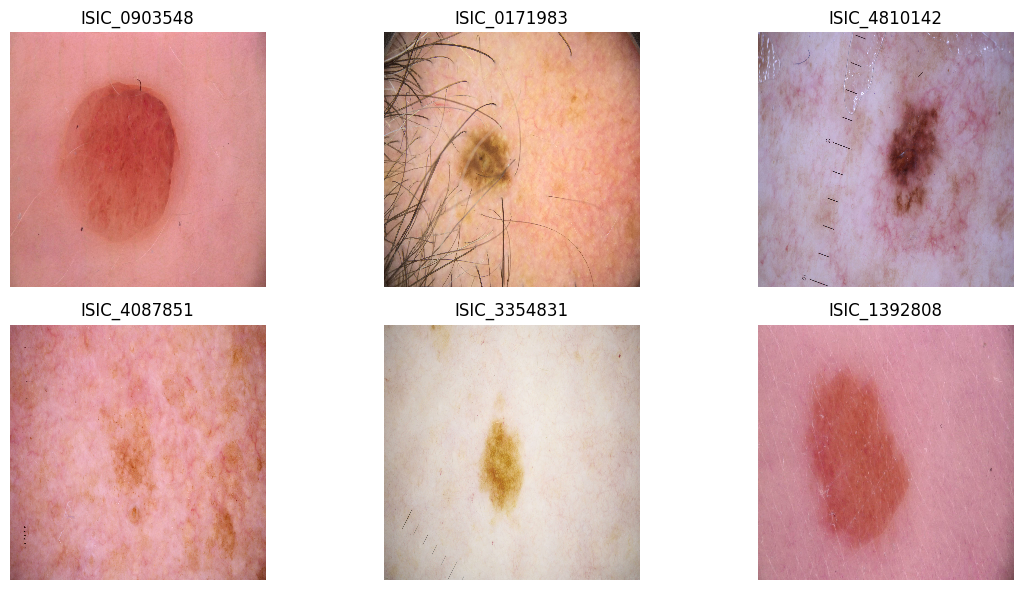

In [124]:
sample_paths = random.sample(train_paths, min(6, len(train_paths)))

plt.figure(figsize=(12, 6))

for i, path in enumerate(sample_paths):
    image = load_image(path).numpy()

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(Path(path).stem)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [125]:
class VectorQuantizer(layers.Layer):
    def __init__(self, num_embeddings, embedding_dim, beta=0.25, **kwargs):
        super().__init__(**kwargs)

        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.beta = beta

    def build(self, input_shape):
        self.embeddings = self.add_weight(
            shape=(self.embedding_dim, self.num_embeddings),
            initializer="uniform",
            trainable=True,
            name="vq_embeddings"
        )

    def call(self, inputs):
        input_shape = tf.shape(inputs)

        flat_inputs = tf.reshape(inputs, [-1, self.embedding_dim])

        encoding_indices = self.get_code_indices(flat_inputs)

        encodings = tf.one_hot(
            encoding_indices,
            self.num_embeddings
        )

        quantized = tf.matmul(
            encodings,
            self.embeddings,
            transpose_b=True
        )

        quantized = tf.reshape(quantized, input_shape)

        codebook_loss = tf.reduce_mean(
            (quantized - tf.stop_gradient(inputs)) ** 2
        )

        commitment_loss = tf.reduce_mean(
            (tf.stop_gradient(quantized) - inputs) ** 2
        )

        self.add_loss(codebook_loss + self.beta * commitment_loss)

        # Straight-through estimator
        quantized = inputs + tf.stop_gradient(quantized - inputs)

        return quantized

    def get_code_indices(self, flat_inputs):
        similarity = tf.matmul(flat_inputs, self.embeddings)

        distances = (
            tf.reduce_sum(flat_inputs ** 2, axis=1, keepdims=True)
            + tf.reduce_sum(self.embeddings ** 2, axis=0)
            - 2 * similarity
        )

        encoding_indices = tf.argmin(distances, axis=1)

        return encoding_indices

In [126]:
def create_encoder(input_shape, latent_dim):
    encoder_inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(
        32,
        3,
        activation="relu",
        padding="same"
    )(encoder_inputs)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(
        64,
        3,
        activation="relu",
        padding="same"
    )(x)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(
        128,
        3,
        activation="relu",
        padding="same"
    )(x)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(
        256,
        3,
        activation="relu",
        padding="same"
    )(x)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.BatchNormalization()(x)

    encoded = layers.Conv2D(
        latent_dim,
        1,
        padding="same"
    )(x)

    encoder = keras.Model(
        encoder_inputs,
        encoded,
        name="encoder"
    )

    return encoder

In [127]:
def create_decoder(latent_shape):
    decoder_inputs = keras.Input(shape=latent_shape)

    x = layers.UpSampling2D(2)(decoder_inputs)
    x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)

    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)

    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)

    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)

    decoder_outputs = layers.Conv2D(
        3,
        3,
        activation="sigmoid",
        padding="same"
    )(x)

    decoder = keras.Model(
        decoder_inputs,
        decoder_outputs,
        name="decoder"
    )

    return decoder

In [128]:
def connect_vqvae_model(encoder, vector_quantizer, decoder, input_shape):
    vqvae_inputs = keras.Input(shape=input_shape)

    encoded = encoder(vqvae_inputs)

    quantized = vector_quantizer(encoded)

    reconstructed = decoder(quantized)

    vqvae = keras.Model(
        vqvae_inputs,
        reconstructed,
        name="vqvae"
    )

    return vqvae

In [129]:
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)

encoder = create_encoder(
    input_shape=input_shape,
    latent_dim=LATENT_DIM
)

latent_shape = encoder.output_shape[1:]

print("Latent shape:", latent_shape)

vector_quantizer = VectorQuantizer(
    num_embeddings=NUM_EMBEDDINGS,
    embedding_dim=LATENT_DIM,
    beta=BETA,
    name="vector_quantizer"
)

decoder = create_decoder(latent_shape)

vqvae = connect_vqvae_model(
    encoder=encoder,
    vector_quantizer=vector_quantizer,
    decoder=decoder,
    input_shape=input_shape
)

Latent shape: (16, 16, 64)


In [130]:
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 16, 16, 64)     │        16,448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,784 (1.55 MB)

 Trainable params: 405,824 (1.55 MB)

 Non-trainable params: 960 (3.75 KB)

In [131]:
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_8 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 32, 32, 256)    │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_9 (UpSampling2D)  │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_10 (UpSampling2D) │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 128, 128, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_11 (UpSampling2D) │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 256, 256, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 256, 256, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,875 (2.04 MB)

 Trainable params: 535,875 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [132]:
vqvae.summary()

Model: "vqvae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 16, 16, 64)     │       406,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vector_quantizer                │ (None, 16, 16, 64)     │         4,096 │
│ (VectorQuantizer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 256, 256, 3)    │       535,875 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 946,755 (3.61 MB)

 Trainable params: 945,795 (3.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [133]:
vqvae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="mae"
)

In [134]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

In [135]:
history = vqvae.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 34s 935ms/step - loss: 2.5367 - val_loss: 0.2584 - learning_rate: 1.0000e-04
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 31s 935ms/step - loss: 4.2136 - val_loss: 0.2976 - learning_rate: 1.0000e-04
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 30s 900ms/step - loss: 2.9876 - val_loss: 0.3627 - learning_rate: 1.0000e-04
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 29s 881ms/step - loss: 2.9452 - val_loss: 0.4296 - learning_rate: 5.0000e-05
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 29s 886ms/step - loss: 3.1601 - val_loss: 0.4496 - learning_rate: 5.0000e-05
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 29s 883ms/step - loss: 3.3381 - val_loss: 0.4951 - learning_rate: 2.5000e-05


In [136]:
Path("../outputs").mkdir(parents=True, exist_ok=True)

vqvae.save_weights("../outputs/vqvae.weights.h5")

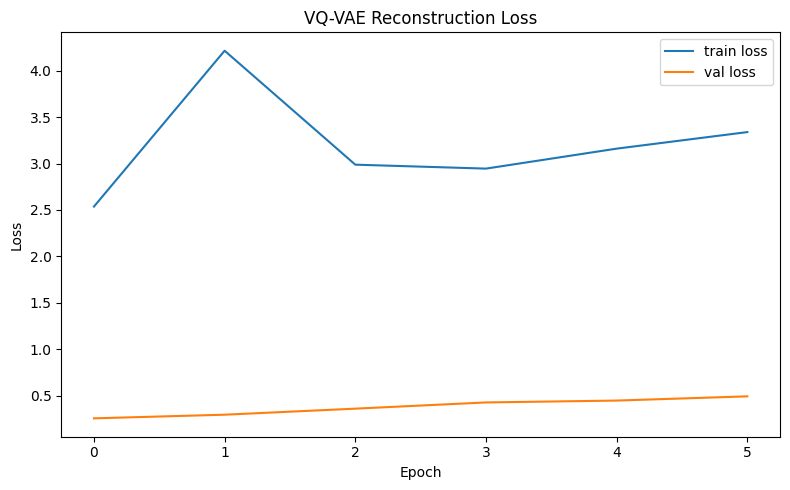

In [137]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="train loss")

if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="val loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VQ-VAE Reconstruction Loss")
plt.legend()
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "vqvae_training_loss.png")
plt.show()

In [138]:
def load_image_as_numpy(path):
    image = load_image(path)
    return image.numpy()

In [139]:
def show_reconstructions(model, paths, n=6):
    sample_paths = random.sample(paths, min(n, len(paths)))

    original_images = np.array([
        load_image_as_numpy(path) for path in sample_paths
    ])

    reconstructed_images = model.predict(
        original_images,
        verbose=0
    )

    n_images = len(sample_paths)

    plt.figure(figsize=(3 * n_images, 6))

    for i in range(n_images):
        plt.subplot(2, n_images, i + 1)
        plt.imshow(original_images[i])
        plt.title("Original")
        plt.axis("off")

        plt.subplot(2, n_images, i + 1 + n_images)
        plt.imshow(np.clip(reconstructed_images[i], 0, 1))
        plt.title("Reconstructed")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(RECON_DIR / "original_vs_reconstructed.png")
    plt.show()

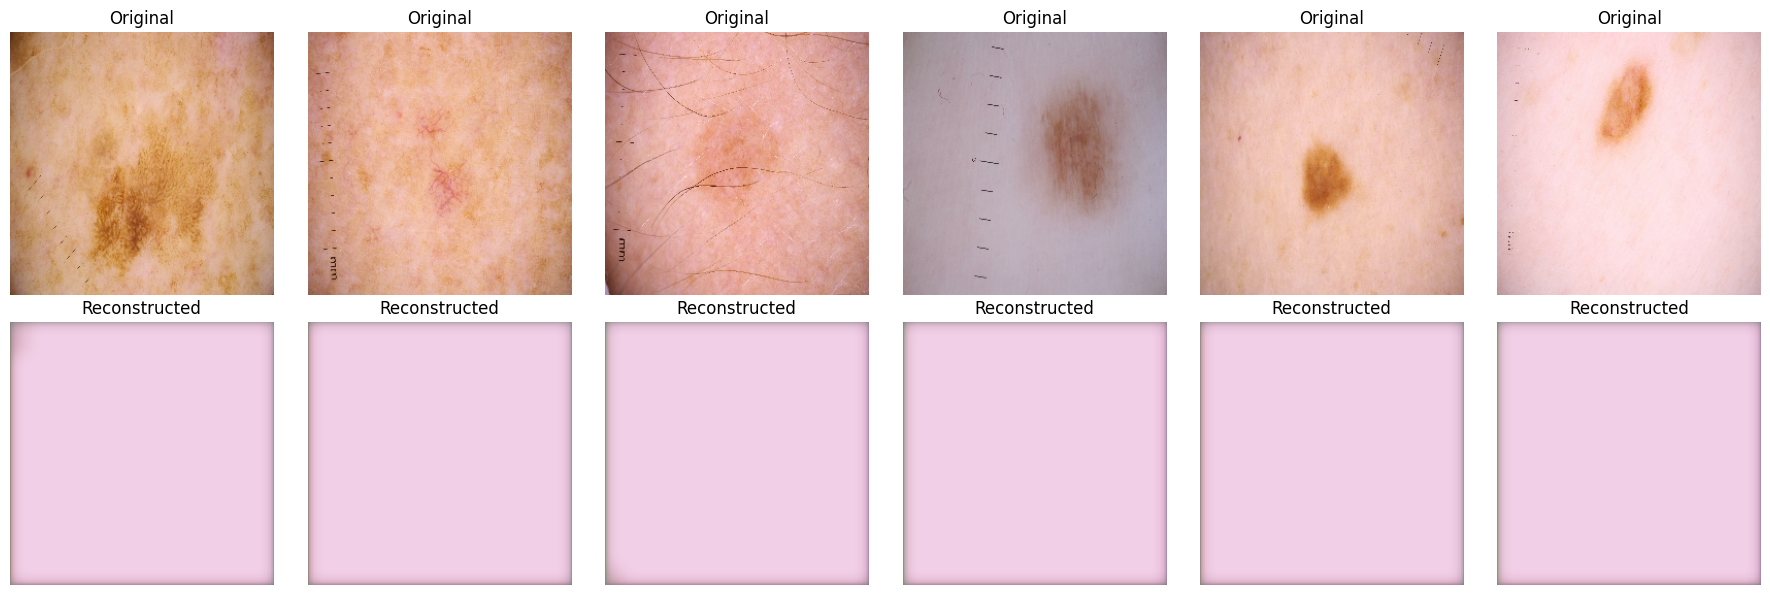

In [140]:
show_reconstructions(vqvae, test_paths, n=6)

In [141]:
def get_code_indices_for_image(image):
    image_batch = np.expand_dims(image, axis=0)

    z = encoder.predict(
        image_batch,
        verbose=0
    )

    flat_z = z.reshape(-1, LATENT_DIM)

    code_indices = vector_quantizer.get_code_indices(
        tf.convert_to_tensor(flat_z, dtype=tf.float32)
    ).numpy()

    code_indices = code_indices.reshape(
        z.shape[1],
        z.shape[2]
    )

    return code_indices

In [142]:
def decode_from_latent(z):
    quantized = vector_quantizer(
        tf.convert_to_tensor(z, dtype=tf.float32)
    )

    decoded = decoder.predict(
        quantized,
        verbose=0
    )[0]

    return decoded

In [143]:
def generate_synthetic_malignant_images(
    source_df,
    n_images=10,
    noise_scale=0.005
):
    malignant_df = source_df[source_df["target"] == 1]

    if len(malignant_df) == 0:
        print("No malignant images found.")
        return

    sample_df = malignant_df.sample(
        n=min(n_images, len(malignant_df)),
        random_state=SEED
    )

    for i, row in enumerate(sample_df.itertuples(), start=1):
        original = load_image_as_numpy(row.filepath)

        image_batch = np.expand_dims(original, axis=0)

        z = encoder.predict(
            image_batch,
            verbose=0
        )

        noise = np.random.normal(
            loc=0.0,
            scale=noise_scale,
            size=z.shape
        ).astype(np.float32)

        z_noisy = z + noise

        synthetic = decode_from_latent(z_noisy)

        synthetic_path = GENERATED_DIR / f"synthetic_malignant_{i:02d}.png"
        comparison_path = GENERATED_DIR / f"comparison_malignant_{i:02d}.png"

        plt.imsave(
            synthetic_path,
            np.clip(synthetic, 0, 1)
        )

        plt.figure(figsize=(8, 4))

        plt.subplot(1, 2, 1)
        plt.imshow(original)
        plt.title("Original malignant")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(np.clip(synthetic, 0, 1))
        plt.title("Synthetic variation")
        plt.axis("off")

        plt.tight_layout()
        plt.savefig(comparison_path)
        plt.close()

    print(f"Generated images saved to: {GENERATED_DIR}")

In [144]:
generation_df = pd.concat(
    [train_df, val_df],
    ignore_index=True
)

generate_synthetic_malignant_images(
    source_df=generation_df,
    n_images=10,
    noise_scale=0.005
)

Generated images saved to: ../outputs/figures/generated


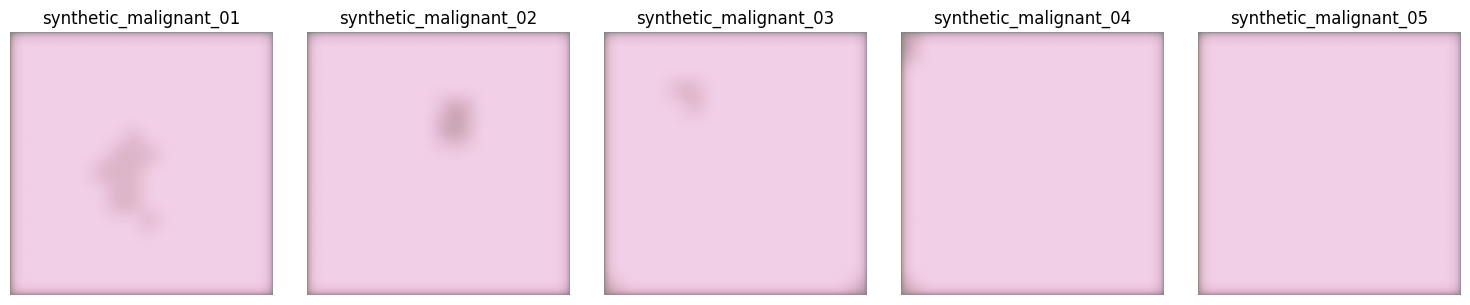

In [145]:
generated_files = sorted(
    GENERATED_DIR.glob("synthetic_malignant_*.png")
)

n = min(5, len(generated_files))

if n > 0:
    plt.figure(figsize=(3 * n, 3))

    for i, path in enumerate(generated_files[:n]):
        img = plt.imread(path)

        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(path.stem)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No generated files found.")

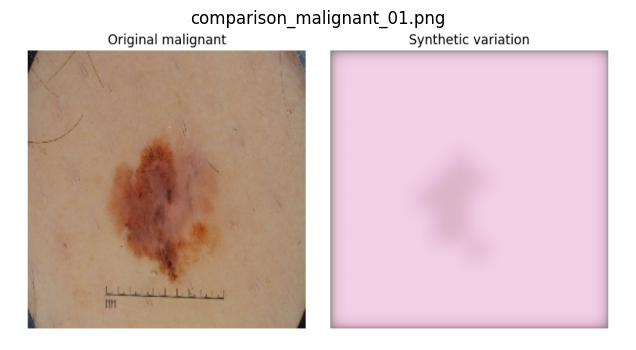

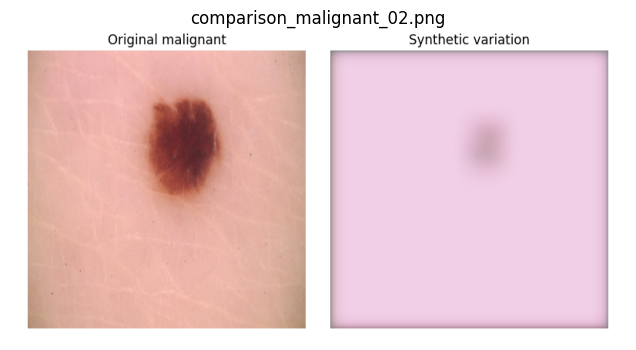

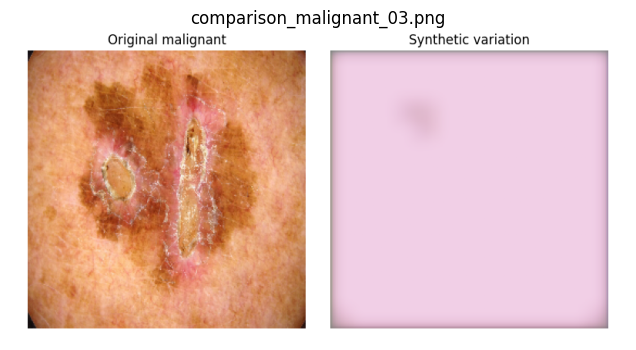

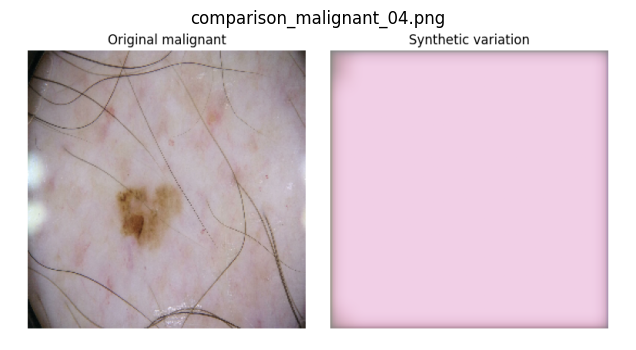

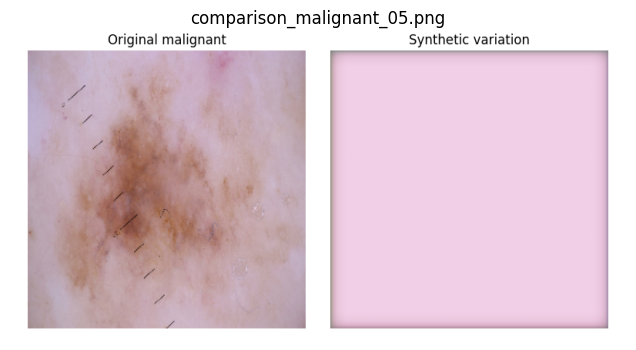

In [146]:
comparison_files = sorted(
    GENERATED_DIR.glob("comparison_malignant_*.png")
)

n = min(5, len(comparison_files))

for path in comparison_files[:n]:
    img = plt.imread(path)

    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.title(path.name)
    plt.axis("off")
    plt.show()

In [147]:
def get_code_indices_for_paths(paths, batch_size=8):
    all_code_indices = []

    for start in range(0, len(paths), batch_size):
        batch_paths = paths[start:start + batch_size]

        batch_images = np.array([
            load_image_as_numpy(path) for path in batch_paths
        ])

        z = encoder.predict(
            batch_images,
            verbose=0
        )

        flat_z = z.reshape(-1, LATENT_DIM)

        code_indices = vector_quantizer.get_code_indices(
            tf.convert_to_tensor(flat_z, dtype=tf.float32)
        ).numpy()

        code_indices = code_indices.reshape(
            z.shape[0],
            -1
        )

        all_code_indices.append(code_indices)

    return np.vstack(all_code_indices)

In [148]:
def compare_codebook_usage(source_df):
    benign_df = source_df[source_df["target"] == 0]
    malignant_df = source_df[source_df["target"] == 1]

    benign_paths = benign_df["filepath"].tolist()
    malignant_paths = malignant_df["filepath"].tolist()

    print("Benign images:", len(benign_paths))
    print("Malignant images:", len(malignant_paths))

    benign_codes = get_code_indices_for_paths(benign_paths)
    malignant_codes = get_code_indices_for_paths(malignant_paths)

    benign_counts = np.bincount(
        benign_codes.flatten(),
        minlength=NUM_EMBEDDINGS
    )

    malignant_counts = np.bincount(
        malignant_codes.flatten(),
        minlength=NUM_EMBEDDINGS
    )

    benign_freq = benign_counts / benign_counts.sum()
    malignant_freq = malignant_counts / malignant_counts.sum()

    codebook_df = pd.DataFrame({
        "codebook_index": np.arange(NUM_EMBEDDINGS),
        "benign_frequency": benign_freq,
        "malignant_frequency": malignant_freq,
        "malignant_minus_benign": malignant_freq - benign_freq
    })

    codebook_df = codebook_df.sort_values(
        "malignant_minus_benign",
        ascending=False
    )

    output_path = CODEBOOK_DIR / "codebook_usage_benign_vs_malignant.csv"

    codebook_df.to_csv(
        output_path,
        index=False
    )

    print(f"Saved codebook usage CSV to: {output_path}")

    return codebook_df

In [149]:
analysis_df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

codebook_df = compare_codebook_usage(analysis_df)

codebook_df.head(10)

Benign images: 1084
Malignant images: 13
Saved codebook usage CSV to: ../outputs/figures/codebook_analysis/codebook_usage_benign_vs_malignant.csv


,codebook_index,benign_frequency,malignant_frequency,malignant_minus_benign
43,43,0.953457,0.972055,0.018599
0,0,0.000000,0.000000,0.000000
48,48,0.000000,0.000000,0.000000
34,34,0.000000,0.000000,0.000000
35,35,0.000000,0.000000,0.000000
36,36,0.000000,0.000000,0.000000
37,37,0.000000,0.000000,0.000000
38,38,0.000000,0.000000,0.000000
39,39,0.000000,0.000000,0.000000
41,41,0.000000,0.000000,0.000000


In [150]:
codebook_df.tail(10).sort_values("malignant_minus_benign")

,codebook_index,benign_frequency,malignant_frequency,malignant_minus_benign
40,40,0.036151,0.025240,-0.010910
12,12,0.010393,0.002704,-0.007688
23,23,0.000000,0.000000,0.000000
24,24,0.000000,0.000000,0.000000
25,25,0.000000,0.000000,0.000000
26,26,0.000000,0.000000,0.000000
27,27,0.000000,0.000000,0.000000
28,28,0.000000,0.000000,0.000000
29,29,0.000000,0.000000,0.000000
63,63,0.000000,0.000000,0.000000


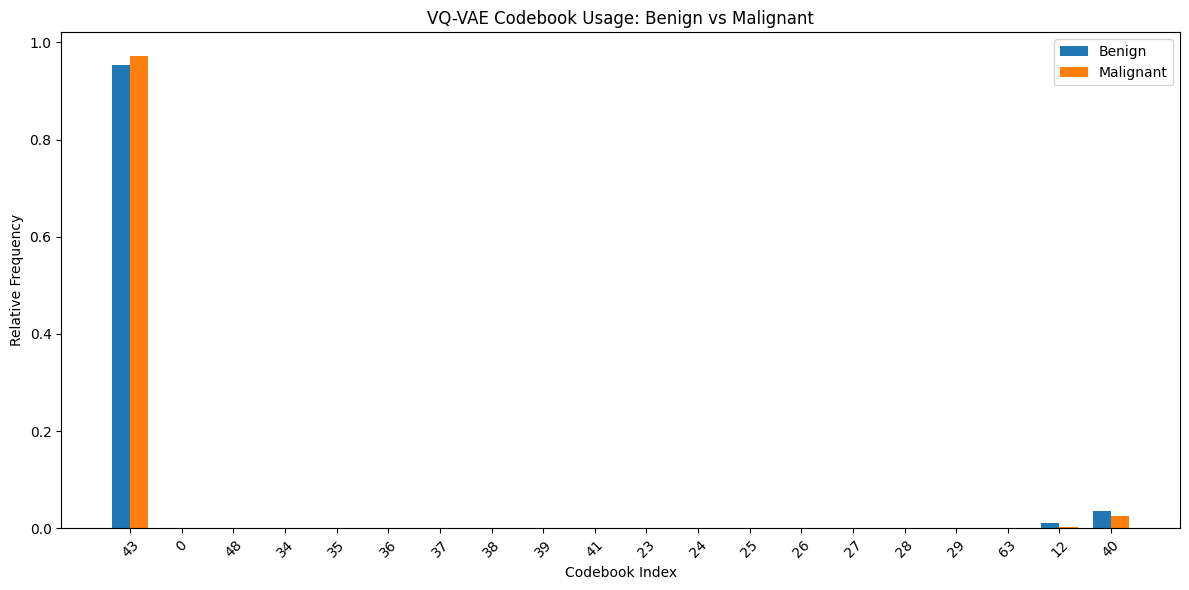

In [151]:
top_malignant_codes = codebook_df.head(10)
top_benign_codes = codebook_df.tail(10)

plot_df = pd.concat([
    top_malignant_codes,
    top_benign_codes
])

plt.figure(figsize=(12, 6))

x = np.arange(len(plot_df))
width = 0.35

plt.bar(
    x - width / 2,
    plot_df["benign_frequency"],
    width,
    label="Benign"
)

plt.bar(
    x + width / 2,
    plot_df["malignant_frequency"],
    width,
    label="Malignant"
)

plt.xticks(
    x,
    plot_df["codebook_index"].astype(str),
    rotation=45
)

plt.xlabel("Codebook Index")
plt.ylabel("Relative Frequency")
plt.title("VQ-VAE Codebook Usage: Benign vs Malignant")
plt.legend()
plt.tight_layout()

plt.savefig(
    CODEBOOK_DIR / "codebook_usage_benign_vs_malignant.png"
)

plt.show()

In [152]:
Path("../outputs/models").mkdir(parents=True, exist_ok=True)

encoder.save("../outputs/models/vqvae_encoder.keras")
decoder.save("../outputs/models/vqvae_decoder.keras")
vqvae.save("../outputs/models/vqvae_full_model.keras")

In [153]:
print("VQ-VAE experiment complete.")
print(f"Reconstructions saved to: {RECON_DIR}")
print(f"Generated images saved to: {GENERATED_DIR}")
print(f"Codebook analysis saved to: {CODEBOOK_DIR}")

VQ-VAE experiment complete.
Reconstructions saved to: ../outputs/figures/reconstructions
Generated images saved to: ../outputs/figures/generated
Codebook analysis saved to: ../outputs/figures/codebook_analysis
